In [254]:
import numpy as np
import scipy
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import odrpack as odr

from uncertainties import ufloat
from uncertainties import umath
from uncertainties import unumpy as un

In [255]:
inFileName = "p5electro.xlsx"

numberOfSheets = len(pd.ExcelFile(inFileName).sheet_names)

intensity=[None]*len(range(numberOfSheets))
alpha=[None]*len(range(numberOfSheets))


for i in range(numberOfSheets):
    df = pd.read_excel(inFileName, sheet_name = i)

    intensity[i] = un.uarray(df["I (A)"].to_numpy(), df["err I"].to_numpy())
    alpha[i] = un.uarray(df["$alpha$"].to_numpy(), df[" err alpha"].to_numpy())


for i in range(numberOfSheets):
    if intensity[i][2].n < 0 :
        intensity[i][:] = -intensity[i][:]



In [256]:
alphaAvg = sum(alpha) / len(alpha)
intensityAvg = sum(intensity) / len(intensity)

'''tanAlpha=[None]*len(range(numberOfSheets))
BaInv=[None]*len(range(numberOfSheets))

for i in range(numberOfSheets):
    tanAlpha[i] = un.tan(np.pi/2-alpha[i]*np.pi/180)
    BaInv[i] = 1/(intensity[i]*0.722)'''

'tanAlpha=[None]*len(range(numberOfSheets))\nBaInv=[None]*len(range(numberOfSheets))\n\nfor i in range(numberOfSheets):\n    tanAlpha[i] = un.tan(np.pi/2-alpha[i]*np.pi/180)\n    BaInv[i] = 1/(intensity[i]*0.722)'

In [257]:
'''tanAlphaAvg = sum(tanAlpha) / len(tanAlpha)
BaInvAvg = sum(BaInv) / len(BaInv)'''

tanAlphaAvg = un.tan(np.pi/2-alphaAvg*np.pi/180)
BaInvAvg = 1/(intensityAvg*0.722*1000)

Y = tanAlphaAvg
X = BaInvAvg

In [258]:
#=============================== Blocón de ODR_FIT ===============================

def func(x, beta):
    return beta[0] * x + beta[1]

beta0 = [0.03,0]

fittingX = un.nominal_values(X)
fittingY = un.nominal_values(Y)
fittingXUncertainty = un.std_devs(X)
fittingYUncertainty = un.std_devs(Y)

sol = odr.odr_fit(func, fittingX, fittingY, beta0, weight_x = 1/(fittingXUncertainty**2), weight_y = 1/(fittingYUncertainty**2))

pendiente = ufloat(sol.beta[0],sol.sd_beta[0])#np.sqrt(sol.cov_beta[0,0]))
ordenada = ufloat(sol.beta[1],sol.sd_beta[1])#np.sqrt(sol.cov_beta[1,1]))

print("pendiente = {:.4f}".format(pendiente))
print("ordenada = {:.4f}".format(ordenada))

print(f"χ² reducido = {sol.sum_square/(len(un.nominal_values(X))-len(sol.beta))}")
#print(f"pearson = {scipy.stats.pearsonr(fittingX, fittingY).statistic}")
print(f"R² = {scipy.stats.pearsonr(fittingX, fittingY).statistic**2}")

#=================================================================================

pendiente = 27.6978+/-0.2622
ordenada = 0.0002+/-0.0028
χ² reducido = 0.4290753525052191
R² = 0.9997245891758312


In [259]:
print("campo magnético B_a = {:.2f} mT".format(pendiente))

campo magnético B_a = 27.70+/-0.26 mT


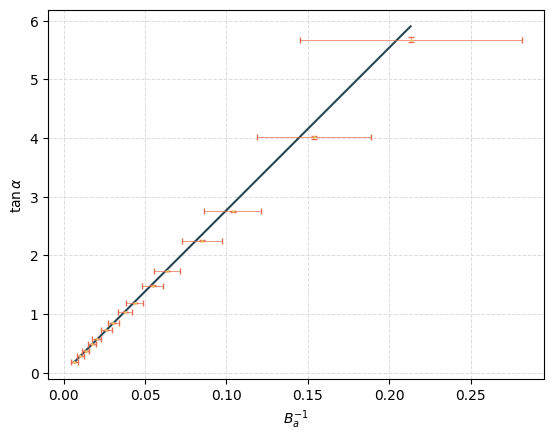

In [260]:
fig, ax = plt.subplots(dpi = 100)

ax.errorbar(un.nominal_values(X),un.nominal_values(Y), un.std_devs(X), un.std_devs(Y), color = "#e9c46a", ls = "", marker = ".", markersize = 2, ecolor = "#e76f51", capsize=2, zorder = 10, elinewidth=.5)

ax.plot(un.nominal_values(X), func(un.nominal_values(X), sol.beta), color = "#264653")

ax.set(xlabel = "$B_a^{-1}$", ylabel = "$\\tan{\\alpha}$ ")

ax.grid(zorder=0,color='gainsboro', linestyle='--', linewidth=0.7)

#plt.savefig("calibracion.png", bbox_inches = "tight")

plt.show()

In [261]:
tanAlpha=[None]*len(range(numberOfSheets))
BaInv=[None]*len(range(numberOfSheets))

for i in range(numberOfSheets):
    tanAlpha[i] = un.tan(np.pi/2-alpha[i]*np.pi/180)
    BaInv[i] = 1/(intensity[i]*0.722*1000)

Y = tanAlpha
X = BaInv

In [262]:
#=============================== BlocónDos de ODR_FIT ===============================

def func(x, beta):
    return beta[0] * x + beta[1]

pendiente = [None]*len(range(numberOfSheets))
ordenada = [None]*len(range(numberOfSheets))
sol = [None]*len(range(numberOfSheets))

for i in range(numberOfSheets):
    beta0 = [0.03,0]

    fittingX = un.nominal_values(X[i])
    fittingY = un.nominal_values(Y[i])
    fittingXUncertainty = un.std_devs(X[i])
    fittingYUncertainty = un.std_devs(Y[i])

    sol[i] = odr.odr_fit(func, fittingX, fittingY, beta0, weight_x = 1/(fittingXUncertainty**2), weight_y = 1/(fittingYUncertainty**2))

    pendiente[i] = ufloat(sol[i].beta[0],np.sqrt(sol[i].cov_beta[0,0]))
    ordenada[i] = ufloat(sol[i].beta[1],np.sqrt(sol[i].cov_beta[1,1]))

    print("pendiente = {:.3f}".format(pendiente[i]))
    print("ordenada = {:.3f}".format(ordenada[i]))

    print(f"χ² reducido = {sol[i].sum_square/(len(un.nominal_values(X))-len(sol[i].beta))}")
    #print(f"pearson = {scipy.stats.pearsonr(fittingX, fittingY).statistic}")
    print(f"R² = {scipy.stats.pearsonr(fittingX, fittingY).statistic**2}")

#=================================================================================

pendiente = 25.598+/-0.938
ordenada = 0.022+/-0.010
χ² reducido = 1.306053771091591
R² = 0.9983986685295039
pendiente = 30.022+/-1.093
ordenada = -0.036+/-0.012
χ² reducido = 0.2950710037207547
R² = 0.9989683048996293
pendiente = 28.764+/-0.926
ordenada = 0.023+/-0.009
χ² reducido = 1.1126947868679598
R² = 0.9969869240935954
pendiente = 28.985+/-1.093
ordenada = -0.035+/-0.013
χ² reducido = 0.8479011724616898
R² = 0.995714563121696
pendiente = 29.011+/-1.121
ordenada = -0.043+/-0.013
χ² reducido = 0.8542500867612397
R² = 0.9939189913326684
pendiente = 25.877+/-0.871
ordenada = 0.033+/-0.009
χ² reducido = 1.019362733117419
R² = 0.9915350227907821


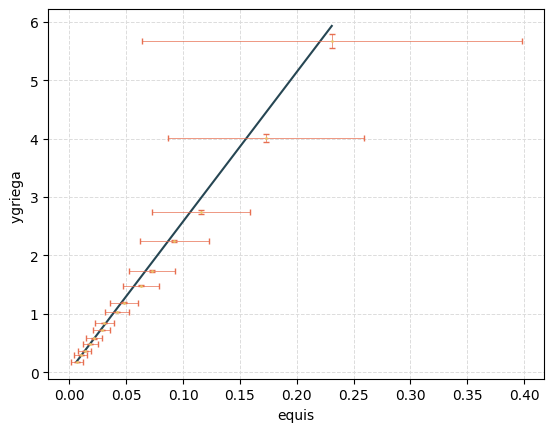

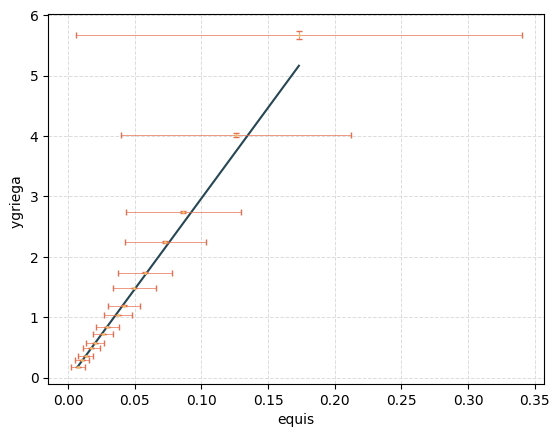

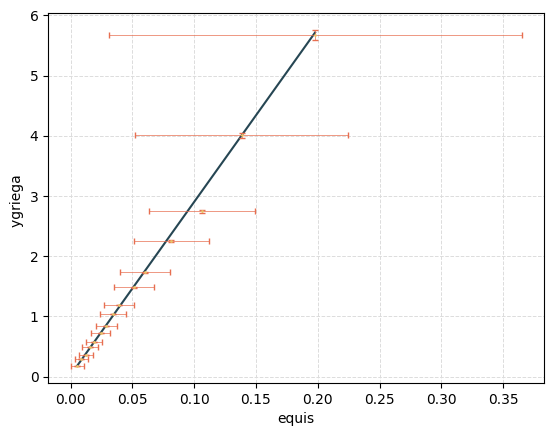

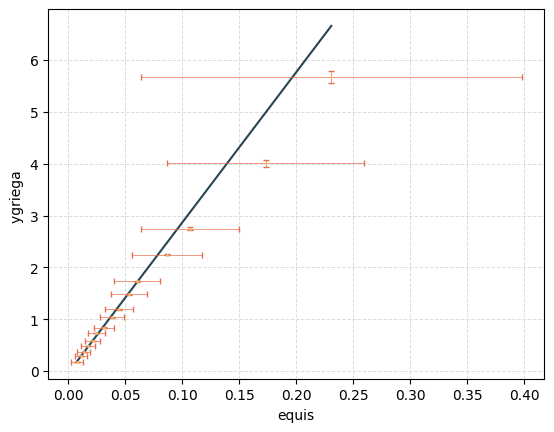

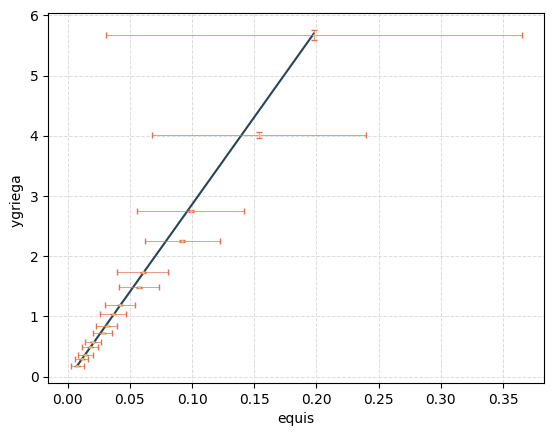

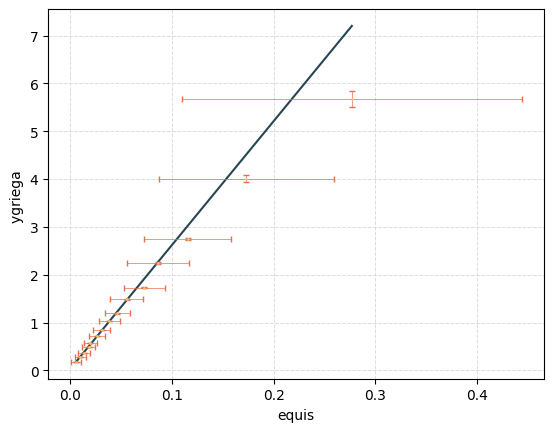

In [263]:
for i in range(numberOfSheets):
    fig, ax = plt.subplots(dpi = 100)

    ax.errorbar(un.nominal_values(X[i]),un.nominal_values(Y[i]), un.std_devs(X[i]), un.std_devs(Y[i]), color = "#e9c46a", ls = "", marker = ".", markersize = 2, ecolor = "#e76f51", capsize=2, zorder = 10, elinewidth=.5)

    ax.plot(un.nominal_values(X[i]), func(un.nominal_values(X[i]), sol[i].beta), color = "#264653")

    ax.set(xlabel = "equis", ylabel = "ygriega ")

    ax.grid(zorder=0,color='gainsboro', linestyle='--', linewidth=0.7)

    #plt.savefig("calibracion.png", bbox_inches = "tight")

    plt.show()